# Extraction Pipeline

This notebook runs the full ingestion pipeline: recursive chunking, vector index construction,
triple extraction, entity resolution, validation, and Supermemory storage. Every expensive step
caches to `data/` so reruns skip completed work.

We are taking data from the first notebook outputs:  `data/schema.json`, `data/detected_chapters.json`, raw book texts in `data/`.

### Setup and Data Loading

In [1]:
from __future__ import annotations
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(Path("../.env"))
import json, os, re, sys
import nltk
nltk.download('punkt_tab', quiet=True)
sys.path.insert(0, str(Path("..").resolve()))
import instructor
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
import asyncio
from openai import OpenAI, AsyncOpenAI
from pydantic import BaseModel, Field
from src.models import (ChapterDetectionResult, EntityType, ExtractionResponse,OntologySchema, RelationshipType, Triple)

In [2]:
from google.oauth2 import service_account
import google.auth.transport.requests

creds = service_account.Credentials.from_service_account_file(
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"],
    scopes=["https://www.googleapis.com/auth/cloud-platform"])
creds.refresh(google.auth.transport.requests.Request())

project = os.environ["GCP_PROJECT"]
location = os.environ["GCP_LOCATION"]
os.environ["OPENAI_BASE_URL"] = (
    f"https://{location}-aiplatform.googleapis.com/v1beta1/"
    f"projects/{project}/locations/{location}/endpoints/openapi")
os.environ["OPENAI_API_KEY"] = creds.token

import vertexai
vertexai.init(project=project, location=location)
from vertexai.language_models import TextEmbeddingModel, TextEmbeddingInput

def refresh_credentials() -> None:
    """
    Refresh the GCP access token if it is expired or will expire within 5 minutes.
    Call before creating a new AsyncOpenAI client.
    """
    import datetime
    remaining = (creds.expiry - datetime.datetime.utcnow()).total_seconds() if creds.expiry else 0
    if not creds.valid or remaining < 300:
        creds.refresh(google.auth.transport.requests.Request())
        os.environ["OPENAI_API_KEY"] = creds.token


In [3]:
data_dir: Path = Path("../data")

book_metadata: dict[str, dict[str, str]] = {
    "shakespeare_complete": {"title": "Complete Works of Shakespeare", "author": "William Shakespeare", "genre": "Drama / Poetry"},
    "beowulf": {"title": "Beowulf", "author": "Anonymous", "genre": "Epic Poetry"},
    "prince": {"title": "The Prince", "author": "Niccolo Machiavelli", "genre": "Political Philosophy"},
    "count_of_monte_cristo": {"title": "The Count of Monte Cristo", "author": "Alexandre Dumas", "genre": "Adventure"},
    "dracula": {"title": "Dracula", "author": "Bram Stoker", "genre": "Gothic Horror"},
    "frankenstein": {"title": "Frankenstein", "author": "Mary Shelley", "genre": "Gothic Horror / Sci-Fi"},
    "pride_and_prejudice": {"title": "Pride and Prejudice", "author": "Jane Austen", "genre": "Comedy of Manners"},
    "alice_in_wonderland": {"title": "Alice's Adventures in Wonderland", "author": "Lewis Carroll", "genre": "Fantasy"},
    "great_gatsby": {"title": "The Great Gatsby", "author": "F. Scott Fitzgerald", "genre": "Modernist Fiction"}}

In [4]:
def split_by_detected_chapters(text: str, result: ChapterDetectionResult, min_len: int = 200) -> list[tuple[str, str]]:
    """
    Split text at detected headings. Uses exact match for short headings to avoid false positives.
    """
    heading_set: set[str] = set(result.headings)
    lines: list[str] = text.split("\n")
    last_seen: dict[str, int] = {}
    char_pos: int = 0
    
    for line in lines:
        stripped: str = line.strip()
        matched = next(
            (h for h in heading_set
             if ((stripped == h) if len(h) <= 5 else (stripped.startswith(h) or h.startswith(stripped)))),
            None)
        if matched:
            last_seen[matched] = char_pos
        char_pos += len(line) + 1

    positions: list[tuple[int, str]] = sorted(((pos, h) for h, pos in last_seen.items()))
    chapters: list[tuple[str, str]] = []

    for i, (pos, heading) in enumerate(positions):
        end: int = positions[i + 1][0] if i + 1 < len(positions) else len(text)
        body: str = text[pos + len(heading):end].strip()
        if len(body) > min_len:
            chapters.append((heading, body))

    return chapters

In [5]:
schema = OntologySchema(**json.loads((data_dir / "schema.json").read_text()))

detected = {
    k: ChapterDetectionResult(**v)
    for k, v in json.loads((data_dir / "detected_chapters.json").read_text()).items()}

corpus: dict[str, str] = {
    key: (data_dir / f"{key}.txt").read_text(encoding="utf-8")
    for key in book_metadata}

book_chapters = {
    key: split_by_detected_chapters(text, detected[key])
    for key, text in corpus.items() if key in detected}

In [6]:
rows = []
for key in corpus:
    meta = book_metadata[key]
    n_ch = len(book_chapters.get(key, []))
    rows.append({"Book": meta["title"], "Words": len(corpus[key].split()), "Chapters": n_ch})
display(pd.DataFrame(rows))
print(f"\nSchema: {len(schema.entity_types)} entity types, "
      f"{len(schema.relationship_types)} relationship types")

,Book,Words,Chapters
0,Complete Works of Shakespeare,966506,43
1,Beowulf,42224,2
2,The Prince,52984,25
3,The Count of Monte Cristo,464025,116
4,Dracula,164356,18
5,Frankenstein,78106,13
6,Pride and Prejudice,130415,10
7,Alice's Adventures in Wonderland,29569,12
8,The Great Gatsby,51262,9



Schema: 8 entity types, 14 relationship types


## Recursive Chunking

Each chapter is split into chunks of approximately 512 tokens, using a 4:1 character-to-token
ratio as a fast approximation to avoid running a tokenizer on every split decision. Sentence
boundaries are detected with NLTK's Punkt tokenizer, which handles abbreviations and edge
cases that a simple regex split on punctuation would miss. Each chunk carries full provenance
metadata (book, author, chapter, position) so downstream agents can trace any retrieved
passage back to its source.

In [7]:
class Chunk(BaseModel):
    text: str
    book_id: str
    book_title: str
    author: str
    chapter_number: int
    chapter_title: str
    chunk_index: int
    total_chunks_in_chapter: int

In [8]:
def chunk_chapter(chapter_body: str, book_id: str, chapter_number: int,
                  chapter_title: str, *, max_tokens: int = 512, chars_per_token: float = 4.0) -> list[Chunk]:
    """
    Split a chapter into ~512-token chunks respecting sentence boundaries.
    """
    max_chars: int = int(max_tokens * chars_per_token)
    sentences: list[str] = nltk.sent_tokenize(chapter_body)
    meta: dict[str, str] = book_metadata[book_id]
    chunks: list[Chunk] = []
    current: list[str] = []
    current_len: int = 0

    def flush_chunk() -> None:
        if current:
            chunks.append(Chunk(
                text=" ".join(current), book_id=book_id,
                book_title=meta["title"], author=meta["author"],
                chapter_number=chapter_number, chapter_title=chapter_title,
                chunk_index=len(chunks), total_chunks_in_chapter=0))

    for sent in sentences:
        if current_len + len(sent) > max_chars and current:
            flush_chunk()
            current, current_len = [], 0
        current.append(sent)
        current_len += len(sent) + 1
    flush_chunk()
    for c in chunks:
        c.total_chunks_in_chapter = len(chunks)
    return chunks

In [9]:
def chunk_all_books(book_chapters: dict[str, list[tuple[str, str]]]) -> list[Chunk]:
    """
    It chunks all our books and then caches to data/recursive_chunks.json.
    """
    cache_path = data_dir / "recursive_chunks.json"

    if cache_path.exists():
        print(f"Loading cached chunks from {cache_path}")
        return [Chunk(**c) for c in json.loads(cache_path.read_text())]

    all_chunks: list[Chunk] = []
    for book_id, chapters in book_chapters.items():
        book_chunks: list[Chunk] = []

        for i, (heading, body) in enumerate(chapters):
            book_chunks.extend(chunk_chapter(body, book_id, i + 1, heading))
        all_chunks.extend(book_chunks)

    cache_path.write_text(json.dumps([c.model_dump() for c in all_chunks], ensure_ascii=False))    
    return all_chunks


chunks: list[Chunk] = chunk_all_books(book_chapters)

Loading cached chunks from ../data/recursive_chunks.json


Total chunks: 5941
Avg chunk size: 331 words
Min: 1, Max: 403


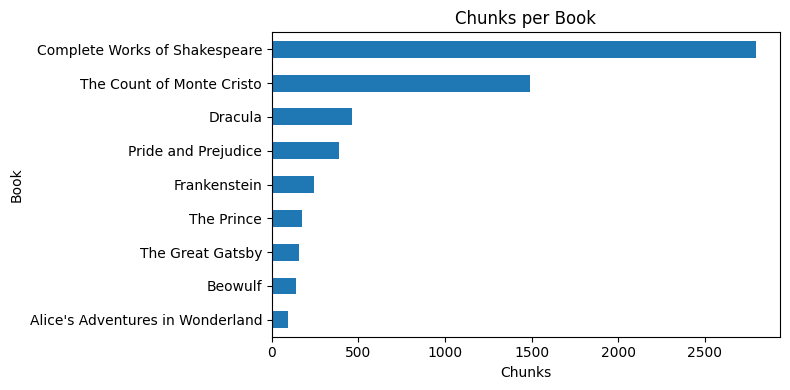

In [10]:
def display_chunk_stats(chunks: list[Chunk]) -> None:
    """
    Displaying chunk statistics and a bar chart of chunks per book.
    """
    df = pd.DataFrame([{"Book": c.book_title, "Words": len(c.text.split())} for c in chunks])
    print(f"Total chunks: {len(chunks)}")
    print(f"Avg chunk size: {df['Words'].mean():.0f} words")
    print(f"Min: {df['Words'].min()}, Max: {df['Words'].max()}")
    counts = df.groupby("Book").size().sort_values()
    counts.plot.barh(title="Chunks per Book", figsize=(8, 4))
    plt.xlabel("Chunks")
    plt.tight_layout()
    plt.show()


display_chunk_stats(chunks)

## Recursive Vector Index (BM25)

BM25 keyword search over the recursive chunks. These chunks have no injected context
words, keeping term frequencies clean for BM25 scoring. This index serves the Vector RAG
Agent for high-specificity factual queries where exact entity names appear in the query.

In [11]:
from rank_bm25 import BM25Okapi

def build_bm25_index(chunks: list[Chunk]) -> BM25Okapi:
    """
    It builds a BM25 index over recursive chunks using rank_bm25.
    """
    tokenized = [c.text.lower().split() for c in chunks]
    return BM25Okapi(tokenized)

bm25_index: BM25Okapi = build_bm25_index(chunks)

In [12]:
def query_bm25(query: str, index: BM25Okapi, chunks: list[Chunk], *, top_k: int = 5, book_id: str | None = None) -> list[tuple[Chunk, float]]:
    """
    Query BM25 index, optionally filtered by book.
    """
    scores = index.get_scores(query.lower().split())
    scored = list(zip(chunks, scores))

    if book_id:
        scored = [(c, s) for c, s in scored if c.book_id == book_id]
    scored.sort(key=lambda x: x[1], reverse=True)
    
    return scored[:top_k]

## Contextual Enrichment

For each recursive chunk, a lightweight model generates a one sentence contextual header
that resolves pronouns and ambiguous references. The enriched chunks are useful for the dense
semantic search index. The header is prepended to the chunk text before embedding so the
vector captures the full narrative context, not just the surface text.

In [13]:
batch_header_prompt = """Generate brief contextual headers for the following passages.
Each header should resolve pronouns and ambiguous references, helping a semantic
search engine understand what the passage is about without reading surrounding text.

{chunks_block}

For EACH passage, write ONE sentence starting with "This passage is from..." that
captures who is involved, what is happening, and where in the narrative this occurs.
Return the headers in order, one per passage.
"""

def format_chunks_block(batch: list) -> str:
    """
    Format a batch of chunks into a numbered prompt block.
    """
    sections: list[str] = []
    
    for i, chunk in enumerate(batch, 1):
        sections.append(
            f"### Passage {i}\n"
            f"Book: {chunk.book_title} by {chunk.author}\n"
            f"Chapter {chunk.chapter_number}: {chunk.chapter_title}\n"
            f"Chunk {chunk.chunk_index + 1} of {chunk.total_chunks_in_chapter}\n\n"
            f"{chunk.text}")

    return "\n\n".join(sections)

In [14]:
class BatchContextualHeaders(BaseModel):
    headers: list[str] = Field(description="Contextual headers in order, one per passage")

class EnrichedChunk(Chunk):
    contextual_header: str

In [15]:
async def enrich_batch(batch: list[Chunk], *, model: str, client: instructor.AsyncInstructor) -> list[EnrichedChunk]:
    """
    Generate contextual headers for a batch of chunks in a single LLM call.
    """
    resp: BatchContextualHeaders = await client.chat.completions.create(
        model=model, response_model=BatchContextualHeaders,
        temperature=0.1,
        messages=[{"role": "user", "content": batch_header_prompt.format(
            chunks_block=format_chunks_block(batch))}])
    return [
        EnrichedChunk(**chunk.model_dump(), contextual_header=header)
        for chunk, header in zip(batch, resp.headers)]

In [16]:
async def enrich_all_chunks(chunks: list[Chunk], *, model: str,
                            batch_size: int = 3, max_concurrent: int = 10) -> list[EnrichedChunk]:
    """
    Enrich all chunks with contextual headers using async batched calls.
    Processes batch_size chunks per LLM call with max_concurrent parallel requests.
    Saves incrementally to disk so interrupted runs can resume.
    """
    cache_path: Path = data_dir / "contextual_chunks.json"

    if cache_path.exists():
        cached: list[EnrichedChunk] = [EnrichedChunk(**c) for c in json.loads(cache_path.read_text())]
        if len(cached) >= len(chunks):
            print(f"Loading {len(cached)} cached enriched chunks")
            return cached[:len(chunks)]
        print(f"Resuming from {len(cached)}/{len(chunks)} cached chunks")
    else:
        cached = []

    remaining: list[Chunk] = chunks[len(cached):]
    sem: asyncio.Semaphore = asyncio.Semaphore(max_concurrent)
    batches: list[list[Chunk]] = [remaining[i:i + batch_size] for i in range(0, len(remaining), batch_size)]
    wave_size: int = 34  # ~100 chunks per wave

    for w in range(0, len(batches), wave_size):
        refresh_credentials()
        client = instructor.from_openai(AsyncOpenAI(), mode=instructor.Mode.JSON)

        async def bounded(batch: list[Chunk]) -> list[EnrichedChunk]:
            async with sem:
                return await enrich_batch(batch, model=model, client=client)

        wave: list[list[Chunk]] = batches[w:w + wave_size]
        results: list[list[EnrichedChunk]] = await asyncio.gather(*[bounded(b) for b in wave])
        for batch_result in results:
            cached.extend(batch_result)
        cache_path.write_text(json.dumps([c.model_dump() for c in cached], ensure_ascii=False))
        print(f"  Enriched {len(cached)}/{len(chunks)} chunks (saved)")

    return cached


enriched: list[EnrichedChunk] = await enrich_all_chunks(chunks, model="google/gemini-2.5-flash")

Loading 5941 cached enriched chunks


## Contextual Vector Index (Dense)

Dense semantic search over enriched chunks. Each chunk is embedded as `header + text`
using Vertex AI text-embedding-005 with asymmetric task types: `RETRIEVAL_DOCUMENT` at
index time, `RETRIEVAL_QUERY` at search time. We will then use cosine similarity with L2-Normalization over numpy arrays.

They will stay in memory, even though for production we would move to a vector database. We are also working in batches, since the texts are chunks are quite a lot and we don't want to hit API limits. Moreover, we want to retrieve onmly the failed butch in cass of possible failure. 

In [17]:
def embed_all_chunks(enriched: list[EnrichedChunk], *, embedding_model: TextEmbeddingModel, batch_size: int = 100) -> np.ndarray:
    """
    Embedding enriched chunks (header + text). Cached then to .npy file for later usage.
    """
    cache_path = data_dir / "contextual_embeddings.npy"

    if cache_path.exists():
        return np.load(cache_path)

    all_embeddings: list[list[float]] = []

    for i in range(0, len(enriched), batch_size):
        batch = enriched[i:i + batch_size]
        inputs = [TextEmbeddingInput(
            text=f"{c.contextual_header}\n\n{c.text}",
            task_type="RETRIEVAL_DOCUMENT") for c in batch]
        results = embedding_model.get_embeddings(inputs)
        all_embeddings.extend([r.values for r in results])

    arr = np.array(all_embeddings, dtype=np.float32)
    np.save(cache_path, arr)

    return arr

embedding_model = TextEmbeddingModel.from_pretrained("text-embedding-005")
embeddings: np.ndarray = embed_all_chunks(enriched, embedding_model=embedding_model, batch_size=25)

Now we write a testing function we will use later to run a few test queries and confirm the dense index returns good results before moving on to the agentic layer. 

In [18]:
def query_dense(query: str, embeddings: np.ndarray, chunks: list[EnrichedChunk], *, embedding_model: TextEmbeddingModel, top_k: int = 5, book_id: str | None = None) -> list[tuple[EnrichedChunk, float]]:
    """
    Dense cosine similarity search over contextual embeddings.
    """
    q_input = TextEmbeddingInput(text=query, task_type="RETRIEVAL_QUERY")
    q_vec = np.array(embedding_model.get_embeddings([q_input])[0].values, dtype=np.float32)
    norms = np.linalg.norm(embeddings, axis=1) * np.linalg.norm(q_vec)
    scores = (embeddings @ q_vec) / np.where(norms > 0, norms, 1.0)
    indices = np.argsort(scores)[::-1]

    results: list[tuple[EnrichedChunk, float]] = []

    for idx in indices:
        if book_id and chunks[idx].book_id != book_id:
            continue
        results.append((chunks[idx], float(scores[idx])))
        if len(results) >= top_k:
            break
        
    return results

## Triple Extraction

Extract schema-constrained triples from every recursive chunk. Each triple links a subject entity to an object entity through a typed relationship, grounded by the exact source text.

**Schema refinement:** after an initial extraction pass, CQ gap analysis revealed two missing edge types. Several competency questions ask about consequences ("what happened because of X "), which temporal ordering alone (PRECEDES) cannot answer. Others require grounding events at specific locations, which neither OCCURS_IN (Event - TextualComponent) nor SET_IN (LiteraryWork - Location) can express at event granularity.

We added CAUSES (Event - Event) and OCCURS_AT (Event - Location) to the schema, bringing the total to 14 relationship types. This is a standard post-extraction refinement in CQ-driven ontology engineering.

In [19]:
extraction_prompt = """You are a knowledge graph extraction system for literary texts.

## Schema
Entity types: {entity_types}
Relationship types (with source -> target constraints):
{relationship_details}

## Passage (from {book_title}, {chapter_title})
{passage}

## Task
Extract all (subject, predicate, object) triples from the passage.
Each triple MUST use entity types and relationship types from the schema above.
Each relationship MUST respect its source_type -> target_type constraint.

For each triple provide:
- subject / subject_type: entity name and its type from the schema
- predicate: relationship type from the schema
- object / object_type: entity name and its type from the schema
- confidence: 0.0 to 1.0
- source_text: the exact sentence(s) supporting this triple

Extract only triples explicitly supported by the passage text.
Return ONLY the structured response."""

In [20]:
async def extract_triples(passage: str, schema: OntologySchema, book_title: str, chapter_title: str, *, model: str, client: instructor.AsyncInstructor) -> ExtractionResponse:
    """
    Extracting schema-constrained triples from a single passage.
    """
    et_text: str = ", ".join(schema.entity_type_names())
    rt_details: str = "\n".join(f"  {rt.name}: {rt.source_type} -> {rt.target_type}"
        for rt in schema.relationship_types)

    return await client.chat.completions.create(
        model=model, response_model=ExtractionResponse, temperature=0.1,
        max_retries=2,
        messages=[{"role": "user", "content": extraction_prompt.format(
            entity_types=et_text, relationship_details=rt_details,
            book_title=book_title, chapter_title=chapter_title,
            passage=passage)}])

In [ ]:
async def extract_all_triples(chunks: list[Chunk], schema: OntologySchema, *,
                              model: str, max_concurrent: int = 20) -> dict[str, list[dict]]:
    """
    Extract triples from all chunks, per book. Async with concurrent requests.
    Caches per book so interrupted runs skip completed books.
    """
    all_triples: dict[str, list[dict]] = {}

    for book_id in sorted({c.book_id for c in chunks}):
        cache_path: Path = data_dir / "triples" / "raw" / f"raw_triples_{book_id}.json"
        if cache_path.exists():
            all_triples[book_id] = json.loads(cache_path.read_text())
            print(f"  {book_id}: loaded {len(all_triples[book_id])} cached triples")
            continue

        sem: asyncio.Semaphore = asyncio.Semaphore(max_concurrent)
        book_chunks: list[Chunk] = [c for c in chunks if c.book_id == book_id]
        partial_path: Path = data_dir / "triples" / "raw" / f"raw_triples_{book_id}.partial.json"

        if partial_path.exists():
            triples: list[dict] = json.loads(partial_path.read_text())
            done_keys: set[tuple] = {(t["chapter_number"], t["chunk_index"]) for t in triples}
            book_chunks = [c for c in book_chunks if (c.chapter_number, c.chunk_index) not in done_keys]
            print(f"  {book_id}: resuming — {len(triples)} triples cached, {len(book_chunks)} chunks remaining")
        else:
            triples: list[dict] = []
        wave_size: int = 80

        for w in range(0, len(book_chunks), wave_size):
            refresh_credentials()
            client = instructor.from_openai(AsyncOpenAI(), mode=instructor.Mode.JSON)

            async def process_chunk(chunk: Chunk, bid: str = book_id, _client=client) -> list[dict]:
                async with sem:
                    try:
                        resp = await extract_triples(
                            chunk.text, schema, chunk.book_title,
                            chunk.chapter_title, model=model, client=_client)
                        results: list[dict] = []
                        for t in resp.triples:
                            d: dict = t.model_dump()
                            d.update(book_id=bid, chapter_number=chunk.chapter_number,
                                     chunk_index=chunk.chunk_index)
                            results.append(d)
                        return results
                    except Exception as e:
                        print(f"WARN: chunk {chunk.chunk_index} ch.{chunk.chapter_number} failed: {e}")
                        return []

            wave: list[Chunk] = book_chunks[w:w + wave_size]
            results: list[list[dict]] = await asyncio.gather(*[process_chunk(c) for c in wave])

            for chunk_triples in results:
                triples.extend(chunk_triples)
            partial_path.write_text(json.dumps(triples, ensure_ascii=False))
            print(f"  {book_id}: {min(w + wave_size, len(book_chunks))}/{len(book_chunks)} chunks (saved)")

        cache_path.write_text(json.dumps(triples, ensure_ascii=False))
        partial_path.unlink(missing_ok=True)
        print(f"  {book_id}: {len(triples)} triples extracted")
        all_triples[book_id] = triples

    return all_triples

all_triples: dict[str, list[dict]] = await extract_all_triples(chunks, schema, model="google/gemini-2.5-pro")

  alice_in_wonderland: loaded 1029 cached triples
  beowulf: loaded 1559 cached triples


/var/folders/92/r9tmfz2j3f320tbngmgd7frm0000gn/T/ipykernel_25646/2097299246.py:26: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  remaining = (creds.expiry - datetime.datetime.utcnow()).total_seconds() if creds.expiry else 0


  count_of_monte_cristo: 80/1493 chunks (saved)
  count_of_monte_cristo: 160/1493 chunks (saved)
  count_of_monte_cristo: 240/1493 chunks (saved)
  count_of_monte_cristo: 320/1493 chunks (saved)
  count_of_monte_cristo: 400/1493 chunks (saved)
  count_of_monte_cristo: 480/1493 chunks (saved)
  count_of_monte_cristo: 560/1493 chunks (saved)
  count_of_monte_cristo: 640/1493 chunks (saved)
  count_of_monte_cristo: 720/1493 chunks (saved)
  count_of_monte_cristo: 800/1493 chunks (saved)
  count_of_monte_cristo: 880/1493 chunks (saved)
  count_of_monte_cristo: 960/1493 chunks (saved)
  count_of_monte_cristo: 1040/1493 chunks (saved)
  count_of_monte_cristo: 1120/1493 chunks (saved)
  count_of_monte_cristo: 1200/1493 chunks (saved)
  count_of_monte_cristo: 1280/1493 chunks (saved)
  count_of_monte_cristo: 1360/1493 chunks (saved)
  count_of_monte_cristo: 1440/1493 chunks (saved)
  count_of_monte_cristo: 1493/1493 chunks (saved)
  count_of_monte_cristo: 17223 triples extracted
  dracula: 80/

In [ ]:
def display_extraction_stats(all_triples: dict[str, list[dict]]) -> None:
    """
    Display extraction statistics with charts for relationship types and entity mentions.
    """
    rows: list[dict] = []
    
    for book_id, triples in all_triples.items():
        rows.append({"Book": book_metadata[book_id]["title"], "Triples": len(triples)})

    display(pd.DataFrame(rows).sort_values("Triples", ascending=False))
    flat: list[dict] = [t for ts in all_triples.values() for t in ts]
    print(f"\nTotal triples: {len(flat)}")
    rel_counts = pd.Series([t["predicate"] for t in flat]).value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    rel_counts.plot.barh(ax=axes[0], title="Triples per Relationship Type")
    ent_types: list[str] = [t["subject_type"] for t in flat] + [t["object_type"] for t in flat]
    pd.Series(ent_types).value_counts().plot.barh(ax=axes[1], title="Entity Mentions per Type")
    plt.tight_layout()
    plt.show()

display_extraction_stats(all_triples)

## Alias Generation

For each unique entity extracted per book, a lightweight model generates alternative names,
titles, and descriptive references. These aliases feed the entity resolution step: without them,
RapidFuzz has no reference set to match against, and surface-form variations become orphan
nodes in the graph.

In [ ]:
alias_prompt = """You are generating aliases for an entity in a literary text.
Entity names often vary: \"the creature,\" \"the monster,\" \"Frankenstein's creation\"
all refer to the same character.

## Entity
Name: {entity_name}
Type: {entity_type}
Book: {book_title}

## Task
List all alternative names, titles, epithets, and descriptive references a reader
might use when referring to this entity. Include:
- Shortened names, nicknames, titles (Mr., Dr., Lord, etc.)
- Descriptive references ("the creature", "the old man")
- Relational references ("Elizabeth's husband", "Darcy's sister")

Do NOT include the canonical name itself. Return 3-15 aliases.
Return ONLY the structured response."""

In [ ]:
class AliasResponse(BaseModel):
    aliases: list[str] = Field(description="Alternative names, titles, and references")

class EntityWithAliases(BaseModel):
    canonical_name: str
    entity_type: str
    book_id: str
    aliases: list[str]

In [ ]:
def generate_aliases_for_entity(entity_name: str, entity_type: str, book_id: str, *, model: str) -> EntityWithAliases:
    """
    Generate aliases for a single entity.
    """
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)
    resp: AliasResponse = client.chat.completions.create(
        model=model, response_model=AliasResponse, temperature=0.2,
        messages=[{"role": "user", "content": alias_prompt.format(
            entity_name=entity_name, entity_type=entity_type,
            book_title=book_metadata[book_id]["title"])}])

    return EntityWithAliases(canonical_name=entity_name, entity_type=entity_type, book_id=book_id, aliases=resp.aliases)

In [ ]:
def generate_aliases_for_book(triples: list[dict], book_id: str, *, model: str) -> list[EntityWithAliases]:
    """
    Generate aliases for all unique entities in a book. Caches per book.
    """
    cache_path = data_dir / "triples" / f"aliases_{book_id}.json"
    if cache_path.exists():
        print(f"  {book_id}: loading from cache")
        return [EntityWithAliases(**e) for e in json.loads(cache_path.read_text())]

    entities: dict[str, str] = {}
    for t in triples:
        entities[t["subject"]] = t["subject_type"]
        entities[t["object"]] = t["object_type"]

    results: list[EntityWithAliases] = []
    for i, (name, etype) in enumerate(entities.items()):
        results.append(generate_aliases_for_entity(
            name, etype, book_id, model=model))
        if (i + 1) % 10 == 0:
            print(f"  {book_id}: {i + 1}/{len(entities)} entities")

    cache_path.write_text(json.dumps(
        [e.model_dump() for e in results], ensure_ascii=False))
    print(f"  {book_id}: {len(results)} entities with aliases")
    return results


all_aliases: dict[str, list[EntityWithAliases]] = {
    book_id: generate_aliases_for_book(triples, book_id, model=)
    for book_id, triples in all_triples.items()}

In [ ]:
def display_alias_network(aliases: list[EntityWithAliases], max_entities: int = 10) -> None:
    """
    Display a sample alias network using networkx.
    """
    G = nx.Graph()
    for entity in aliases[:max_entities]:
        G.add_node(entity.canonical_name, node_type="canonical")
        for alias in entity.aliases[:5]:
            G.add_node(alias, node_type="alias")
            G.add_edge(entity.canonical_name, alias)

    colors = ["#4169E1" if G.nodes[n].get("node_type") == "canonical"
              else "#87CEEB" for n in G.nodes]
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2, seed=42)
    nx.draw(G, pos, with_labels=True, node_color=colors,
            node_size=800, font_size=8, font_weight="bold")
    plt.title("Sample Alias Network")
    plt.tight_layout()
    plt.show()


display_alias_network(all_aliases["frankenstein"])

## Entity Resolution

Within each book, merge duplicate entity nodes using RapidFuzz weighted ratio matching against
the alias index. This collapses surface-form variations into canonical nodes so the knowledge
graph has one node per real entity, not one node per name variant. Resolution happens per book
to prevent cross-book entity confusion.

In [ ]:
from rapidfuzz import fuzz

class ResolvedEntity(BaseModel):
    canonical_id: str
    canonical_name: str
    entity_type: str
    book_id: str
    merged_names: list[str]

In [ ]:
def build_alias_index(aliases: list[EntityWithAliases]) -> dict[str, str]:
    """
    Build a flat alias -> canonical_name index for one book.
    """
    index: dict[str, str] = {}
    for entity in aliases:
        canonical = entity.canonical_name
        index[canonical.lower()] = canonical
        for alias in entity.aliases:
            index[alias.lower()] = canonical
    return index

In [ ]:
def resolve_entities_in_book(
    triples: list[dict], alias_index: dict[str, str],
    book_id: str, *, threshold: int = 80,
) -> tuple[list[ResolvedEntity], dict[str, str]]:
    """
    Merge duplicate entities using RapidFuzz against the alias index.
    """
    name_map: dict[str, str] = {}
    all_names = {t["subject"] for t in triples} | {t["object"] for t in triples}

    for name in all_names:
        key = name.lower()
        if key in alias_index:
            name_map[name] = alias_index[key]
            continue
        best_match, best_score = None, 0
        for alias, canonical in alias_index.items():
            score = fuzz.WRatio(key, alias)
            if score > best_score:
                best_match, best_score = canonical, score
        name_map[name] = best_match if best_score >= threshold else name

    merged: dict[str, list[str]] = {}
    for original, canonical in name_map.items():
        merged.setdefault(canonical, []).append(original)

    entities = []
    for name, names in merged.items():
        etype = next(
            (t["subject_type"] for t in triples if t["subject"] == name),
            next((t["object_type"] for t in triples if t["object"] == name), "Unknown"))
        entities.append(ResolvedEntity(
            canonical_id=f"{book_id}::{name}", canonical_name=name,
            entity_type=etype, book_id=book_id, merged_names=names))
    return entities, name_map

In [ ]:
def update_triples_with_resolved(triples: list[dict], name_map: dict[str, str]) -> list[dict]:
    """
    Replace entity names in triples with resolved canonical names.
    """
    updated: list[dict] = []
    for t in triples:
        t_new = t.copy()
        t_new["subject"] = name_map.get(t["subject"], t["subject"])
        t_new["object"] = name_map.get(t["object"], t["object"])
        updated.append(t_new)
    return updated


# resolved_triples: dict[str, list[dict]] = {}
# resolved_entities: dict[str, list[ResolvedEntity]] = {}
# for book_id, triples in all_triples.items():
#     alias_idx = build_alias_index(all_aliases[book_id])
#     entities, name_map = resolve_entities_in_book(triples, alias_idx, book_id)
#     resolved_entities[book_id] = entities
#     resolved_triples[book_id] = update_triples_with_resolved(triples, name_map)

In [ ]:
def display_resolution_stats(original: dict[str, list[dict]], resolved: dict[str, list[ResolvedEntity]]) -> None:
    """
    Display entity count before and after resolution per book.
    """
    rows: list[dict] = []
    for book_id in original:
        orig_names: set[str] = {t["subject"] for t in original[book_id]} | {t["object"] for t in original[book_id]}
        res_count: int = len(resolved.get(book_id, []))
        rows.append({"Book": book_metadata[book_id]["title"],
                      "Before": len(orig_names), "After": res_count,
                      "Merged": len(orig_names) - res_count})
    display(pd.DataFrame(rows))


# display_resolution_stats(all_triples, resolved_entities)

## Triple Validation

Offline validation agent. Each triple is scored 0.0-1.0 against its source text using
Instructor with up to 3 retries. Triples scoring >= 0.7 pass to the main set, 0.3-0.7 go
to review, below 0.3 are discarded. This filters extraction noise before the triples
enter Supermemory.

In [ ]:
validation_prompt = """You are a triple validation agent for a literary knowledge graph.

## Triple
Subject: {subject} (type: {subject_type})
Predicate: {predicate}
Object: {object} (type: {object_type})

## Source Text
{source_text}

## Task
Score 0.0 to 1.0 how accurately this triple represents the source text.
- 1.0: triple is explicitly stated in the text
- 0.7: triple is strongly implied by the text
- 0.3: triple is loosely related but not well supported
- 0.0: triple is not supported by the text at all

Provide your score and brief reasoning."""

In [ ]:
class ValidationScore(BaseModel):
    score: float = Field(ge=0.0, le=1.0, description="Accuracy score")
    reasoning: str = Field(description="Brief explanation for the score")

class ValidatedTriple(BaseModel):
    subject: str
    subject_type: str
    predicate: str
    object: str
    object_type: str
    confidence: float
    source_text: str
    book_id: str
    chapter_number: int
    chunk_index: int
    validation_score: float
    validated: bool

In [ ]:
def validate_triple(triple: dict, *, model: str) -> ValidatedTriple:
    """
    Validate a single triple against its source text. Up to 3 retries.
    """
    client = instructor.from_openai(OpenAI(), mode=instructor.Mode.JSON)
    resp: ValidationScore = client.chat.completions.create(
        model=model, response_model=ValidationScore,
        temperature=0.1, max_retries=3,
        messages=[{"role": "user", "content": validation_prompt.format(
            subject=triple["subject"], subject_type=triple["subject_type"],
            predicate=triple["predicate"],
            object=triple["object"], object_type=triple["object_type"],
            source_text=triple["source_text"])}])

    return ValidatedTriple(
        **{k: triple[k] for k in [
            "subject", "subject_type", "predicate", "object", "object_type",
            "confidence", "source_text", "book_id", "chapter_number", "chunk_index"]},
        validation_score=resp.score,
        validated=resp.score >= 0.7)

In [ ]:
def validate_all_triples(
    all_triples: dict[str, list[dict]], *, model: str,
) -> tuple[dict[str, list[dict]], dict[str, list[dict]]]:
    """
    Validate all triples. Returns (validated, review) dicts per book.
    """
    validated: dict[str, list[dict]] = {}
    review: dict[str, list[dict]] = {}

    for book_id, triples in all_triples.items():
        v_path = data_dir / "triples" / f"validated_triples_{book_id}.json"
        r_path = data_dir / "triples" / f"review_triples_{book_id}.json"
        if v_path.exists() and r_path.exists():
            print(f"  {book_id}: loading from cache")
            validated[book_id] = json.loads(v_path.read_text())
            review[book_id] = json.loads(r_path.read_text())
            continue

        v_list, r_list = [], []
        for i, t in enumerate(triples):
            vt = validate_triple(t, model=model)
            d = vt.model_dump()
            if vt.validation_score >= 0.7:
                v_list.append(d)
            elif vt.validation_score >= 0.3:
                r_list.append(d)
            if (i + 1) % 20 == 0:
                print(f"  {book_id}: {i + 1}/{len(triples)} validated")

        v_path.write_text(json.dumps(v_list, ensure_ascii=False))
        r_path.write_text(json.dumps(r_list, ensure_ascii=False))
        print(f"  {book_id}: {len(v_list)} valid, {len(r_list)} review, "
              f"{len(triples) - len(v_list) - len(r_list)} discarded")
        validated[book_id], review[book_id] = v_list, r_list
    return validated, review


# validated, review = validate_all_triples(resolved_triples, model=)

In [ ]:
def display_validation_stats(validated: dict[str, list[dict]], review: dict[str, list[dict]], total: dict[str, list[dict]]) -> None:
    """
    Display validation pass, review, and discard rates per book.
    """
    rows: list[dict] = []
    for book_id in total:
        n: int = len(total[book_id])
        v: int = len(validated.get(book_id, []))
        r: int = len(review.get(book_id, []))
        rows.append({"Book": book_metadata[book_id]["title"], "Total": n,
                      "Validated": v, "Review": r, "Discarded": n - v - r,
                      "Pass Rate": f"{v / n:.1%}" if n else "N/A"})
    display(pd.DataFrame(rows))


# display_validation_stats(validated, review, resolved_triples)

## Supermemory Storage

Store validated triples into Supermemory with per-book containers (`book_{key}`). Each
memory entry carries the source chunk text as content and the full triple metadata. Review
triples go to separate `review_{key}` containers. The content field holds the source text,
not the triple label, because bare triples lose ~35% of answer-relevant information.

In [ ]:
from supermemory import Supermemory

# Initialize client — configure before running
# sm = Supermemory(api_key=os.environ["SUPERMEMORY_API_KEY"])
sm = None

In [ ]:
def store_triple(triple: dict, sm_client: Supermemory, container: str) -> str:
    """
    Store a single validated triple as a memory entry in Supermemory.
    """
    content = triple["source_text"]
    metadata = {
        "entity_from": triple["subject"],
        "entity_from_type": triple["subject_type"],
        "relationship": triple["predicate"],
        "entity_to": triple["object"],
        "entity_to_type": triple["object_type"],
        "book_id": triple.get("book_id", ""),
        "chapter_number": triple.get("chapter_number", 0),
        "chunk_index": triple.get("chunk_index", 0),
        "confidence": triple.get("confidence", 0.0),
        "validation_score": triple.get("validation_score", 0.0),
        "validated": triple.get("validated", False),
    }
    result = sm_client.memory.create(
        content=content, metadata=metadata, container=container)
    return result.id

In [ ]:
def store_all_triples(
    validated: dict[str, list[dict]],
    review: dict[str, list[dict]],
    sm_client: Supermemory,
) -> dict[str, int]:
    """
    Store all validated and review triples into Supermemory containers.
    """
    counts: dict[str, int] = {}
    for book_id, triples in validated.items():
        container = f"book_{book_id}"
        for i, t in enumerate(triples):
            store_triple(t, sm_client, container)
            if (i + 1) % 20 == 0:
                print(f"  {container}: {i + 1}/{len(triples)}")
        counts[container] = len(triples)
        print(f"  {container}: {len(triples)} triples stored")

    for book_id, triples in review.items():
        container = f"review_{book_id}"
        for t in triples:
            store_triple(t, sm_client, container)
        counts[container] = len(triples)
        print(f"  {container}: {len(triples)} review triples stored")
    return counts


# counts = store_all_triples(validated, review, sm)

In [ ]:
def verify_storage(sm_client: Supermemory, container: str, query: str) -> None:
    """
    Run a test query against a Supermemory container.
    """
    results = sm_client.memory.search(
        query=query, container=container, top_k=3)
    print(f"Container: {container}")
    print(f"Query: {query}")
    print(f"Results: {len(results.memories)}")
    for i, mem in enumerate(results.memories):
        print(f"\n  [{i + 1}] Score: {mem.score:.3f}")
        print(f"      Content: {mem.content[:200]}...")
        print(f"      Metadata: {mem.metadata}")


# verify_storage(sm, "book_frankenstein", "Who is Victor Frankenstein?")

## Index Verification

Run one test query per retrieval path (BM25, dense, graph) and display results side by side.
This is a sanity check that all three indexes return sensible results before the agentic
layer is built on top.

In [ ]:
def verify_all_indexes(
    bm25_index: BM25Okapi, chunks: list[Chunk],
    embeddings: np.ndarray, enriched: list[EnrichedChunk],
    *, embedding_model: TextEmbeddingModel,
    sm_client: Supermemory | None = None,
) -> None:
    """
    Run one test query per retrieval path.
    """
    test_queries = {
        "BM25 (keyword)": "Who is Victor Frankenstein?",
        "Dense (semantic)": "What are the consequences of unchecked ambition?",
        "Graph (Supermemory)": "How is the creature related to Victor?",
    }
    for method, query in test_queries.items():
        print(f"\n{'=' * 60}")
        print(f'{method}: "{query}"')
        print("=" * 60)

        if method.startswith("BM25"):
            for c, s in query_bm25(query, bm25_index, chunks, top_k=3):
                print(f"  [{s:.3f}] {c.book_title}, Ch.{c.chapter_number}")
                print(f"          {c.text[:150]}...\n")

        elif method.startswith("Dense"):
            for c, s in query_dense(query, embeddings, enriched,
                                    embedding_model=embedding_model, top_k=3):
                print(f"  [{s:.3f}] {c.book_title}, Ch.{c.chapter_number}")
                print(f"          {c.text[:150]}...\n")

        elif sm_client:
            verify_storage(sm_client, "book_frankenstein", query)


# verify_all_indexes(bm25_index, chunks, embeddings, enriched, embedding_model=)